In [1]:
import seaborn as sns

df = sns.load_dataset('titanic')

In [2]:
print(df.info())
print(df.shape)
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None
(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [15]:
df_null_sum = df.isnull().sum()
null_percentage = (df_null_sum / len(df)) * 100
null_percentage.sort_values()

survived        0.000000
pclass          0.000000
sex             0.000000
sibsp           0.000000
parch           0.000000
fare            0.000000
class           0.000000
who             0.000000
adult_male      0.000000
alive           0.000000
alone           0.000000
embarked        0.224467
embark_town     0.224467
age            19.865320
deck           77.216611
dtype: float64

In [17]:
df['age'].fillna(df['age'].mean(), inplace = True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace = True)
df.drop('deck', axis = 1, inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  embark_town  889 non-null    object  
 12  alive        891 non-null    object  
 13  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 79.4+ KB


/tmp/ipykernel_2602/3218505233.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace = True)


In [25]:
from sklearn.preprocessing import LabelEncoder as le
# le = LabelEncoder()
df['class'] = le().fit_transform(df['class'])

In [26]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,2,man,True,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,0,woman,False,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,2,woman,False,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,0,woman,False,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,2,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,1,man,True,Southampton,no,True
887,1,1,female,19.000000,0,0,30.0000,S,0,woman,False,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.4500,S,2,woman,False,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,0,man,True,Cherbourg,yes,True


In [27]:
import pandas as pd

df = pd.get_dummies(df, columns = ['sex', 'embarked'], drop_first = True)
df

,survived,pclass,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone,sex_male,embarked_Q,embarked_S
0,0,3,22.000000,1,0,7.2500,2,man,True,Southampton,no,False,True,False,True
1,1,1,38.000000,1,0,71.2833,0,woman,False,Cherbourg,yes,False,False,False,False
2,1,3,26.000000,0,0,7.9250,2,woman,False,Southampton,yes,True,False,False,True
3,1,1,35.000000,1,0,53.1000,0,woman,False,Southampton,yes,False,False,False,True
4,0,3,35.000000,0,0,8.0500,2,man,True,Southampton,no,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,27.000000,0,0,13.0000,1,man,True,Southampton,no,True,True,False,True
887,1,1,19.000000,0,0,30.0000,0,woman,False,Southampton,yes,True,False,False,True
888,0,3,29.699118,1,2,23.4500,2,woman,False,Southampton,no,False,False,False,True
889,1,1,26.000000,0,0,30.0000,0,man,True,Cherbourg,yes,True,True,False,False


In [28]:
from sklearn.preprocessing import StandardScaler as scaler

df[['age', 'fare']] = scaler().fit_transform(df[['age', 'fare']])
df

,survived,pclass,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone,sex_male,embarked_Q,embarked_S
0,0,3,-0.592481,1,0,-0.502445,2,man,True,Southampton,no,False,True,False,True
1,1,1,0.638789,1,0,0.786845,0,woman,False,Cherbourg,yes,False,False,False,False
2,1,3,-0.284663,0,0,-0.488854,2,woman,False,Southampton,yes,True,False,False,True
3,1,1,0.407926,1,0,0.420730,0,woman,False,Southampton,yes,False,False,False,True
4,0,3,0.407926,0,0,-0.486337,2,man,True,Southampton,no,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,-0.207709,0,0,-0.386671,1,man,True,Southampton,no,True,True,False,True
887,1,1,-0.823344,0,0,-0.044381,0,woman,False,Southampton,yes,True,False,False,True
888,0,3,0.000000,1,2,-0.176263,2,woman,False,Southampton,no,False,False,False,True
889,1,1,-0.284663,0,0,-0.044381,0,man,True,Cherbourg,yes,True,True,False,False


In [29]:
# create feature
df['fam_size'] = df['sibsp'] + df['parch'] + 1
df

,survived,pclass,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone,sex_male,embarked_Q,embarked_S,fam_size
0,0,3,-0.592481,1,0,-0.502445,2,man,True,Southampton,no,False,True,False,True,2
1,1,1,0.638789,1,0,0.786845,0,woman,False,Cherbourg,yes,False,False,False,False,2
2,1,3,-0.284663,0,0,-0.488854,2,woman,False,Southampton,yes,True,False,False,True,1
3,1,1,0.407926,1,0,0.420730,0,woman,False,Southampton,yes,False,False,False,True,2
4,0,3,0.407926,0,0,-0.486337,2,man,True,Southampton,no,True,True,False,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,-0.207709,0,0,-0.386671,1,man,True,Southampton,no,True,True,False,True,1
887,1,1,-0.823344,0,0,-0.044381,0,woman,False,Southampton,yes,True,False,False,True,1
888,0,3,0.000000,1,2,-0.176263,2,woman,False,Southampton,no,False,False,False,True,4
889,1,1,-0.284663,0,0,-0.044381,0,man,True,Cherbourg,yes,True,True,False,False,1


In [32]:
# split, train, test

from sklearn.model_selection import train_test_split
x = df.drop('survived', axis = 1)
y = df['survived']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)
x_train.shape, x_test.shape

((712, 15), (179, 15))

<Axes: >

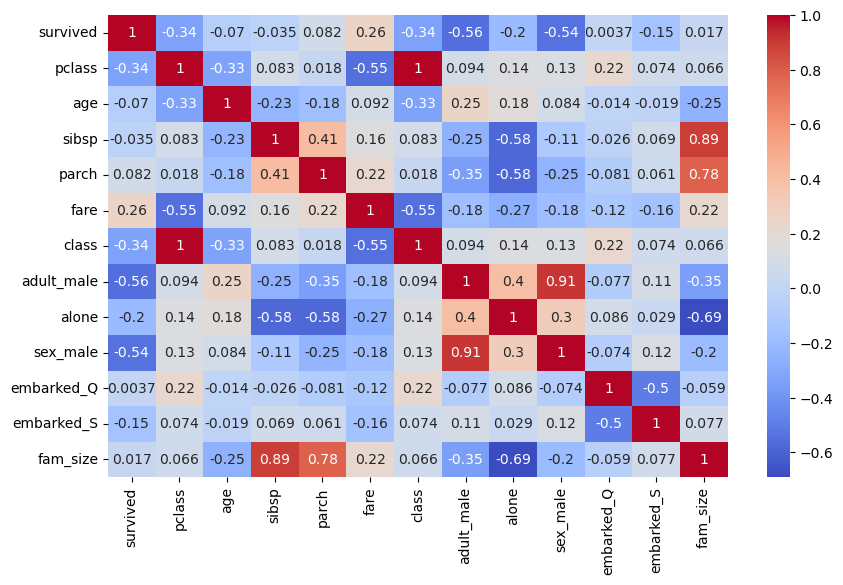

In [35]:
# corr
import matplotlib.pyplot as plt
cor = df.corr(numeric_only = True)
plt.figure(figsize = (10, 6))
sns.heatmap(cor, annot = True, cmap = 'coolwarm')

In [36]:
cor['survived'].sort_values(ascending = False)

survived      1.000000
fare          0.257307
parch         0.081629
fam_size      0.016639
embarked_Q    0.003650
sibsp        -0.035322
age          -0.069809
embarked_S   -0.149683
alone        -0.203367
pclass       -0.338481
class        -0.338481
sex_male     -0.543351
adult_male   -0.557080
Name: survived, dtype: float64